# Customer Churn Analysis

## 1. Project Objective

The objective of this project is to analyze customer churn
and identify the key factors that influence customer retention.

## 2. Dataset

The dataset contains information about 7,043 customers,
including demographics, services, billing information, and churn status.

## 1. Real Customer | Real Churn


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
customers = pd.read_csv('Telco-Customer-Churn.csv')
customers.shape
customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 2. Real Data Preview


In [46]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [47]:
customers.describe()
customers.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [48]:
customers['TotalCharges'] = customers['TotalCharges'].replace(" ", '0').astype(float)

In [49]:
customers.describe(include='object')

C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\2762918133.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  customers.describe(include='object')


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,5174


In [50]:
def conv(value):
    if value == 1:
        return 'Yes'
    else:
        return 'No'
customers['SeniorCitizen'] = customers['SeniorCitizen'].apply(conv)

In [51]:
customers.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,2,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,No,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,5901,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,NaN,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,NaN,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,NaN,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


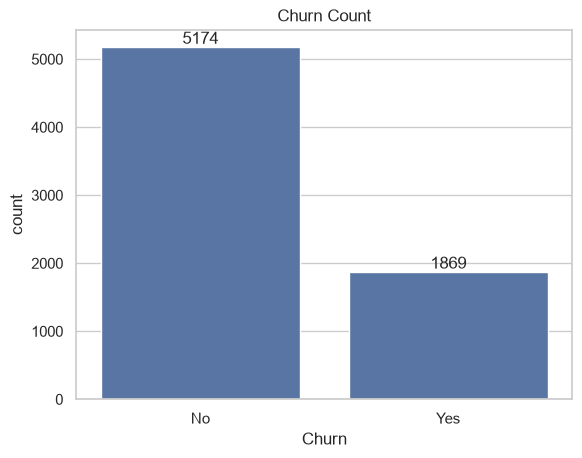

In [52]:
ax = sns.countplot(x='Churn',data=customers)

ax.bar_label(ax.containers[0])
plt.title('Churn Count')
plt.show()

In [53]:
gb = customers.groupby('Churn').agg({'Churn': 'count'})

gb

,Churn
Churn,
No,5174
Yes,1869


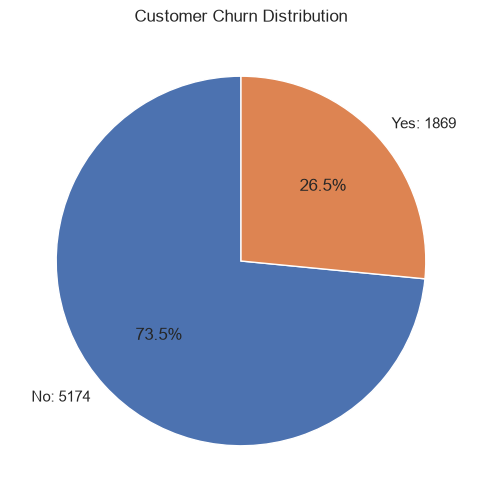

In [54]:
churn_counts = customers['Churn'].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    churn_counts,
    labels=[f'{label}: {count}' for label, count in churn_counts.items()],
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Churn Distribution')
plt.show()

## Customers Churn by Gender 

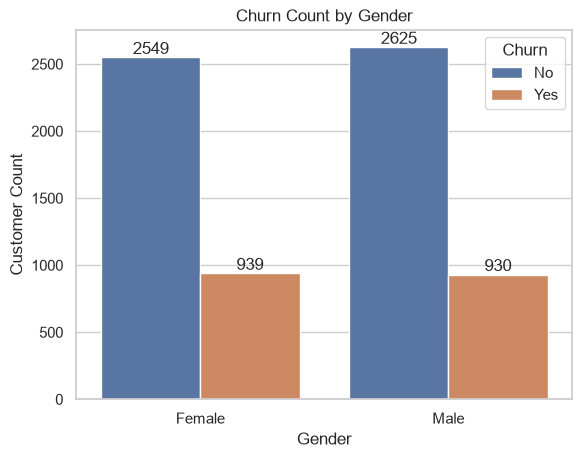

In [55]:
ax = sns.countplot(x='gender', hue='Churn', data=customers)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Count')

plt.show()

# Female Customers more  churn out acc to Male Customers 


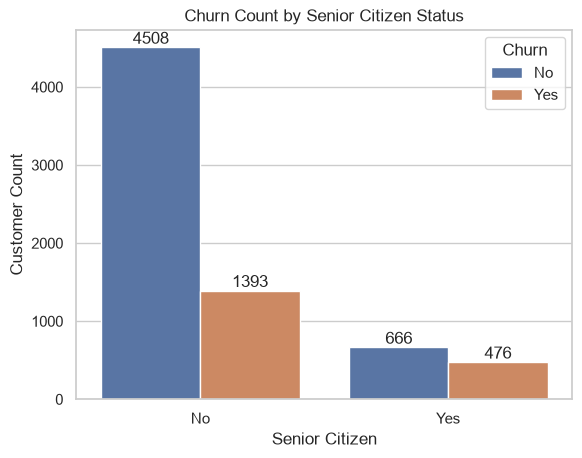

In [56]:
ax = sns.countplot(x='SeniorCitizen', hue='Churn', data=customers)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Count by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Customer Count')

plt.show()

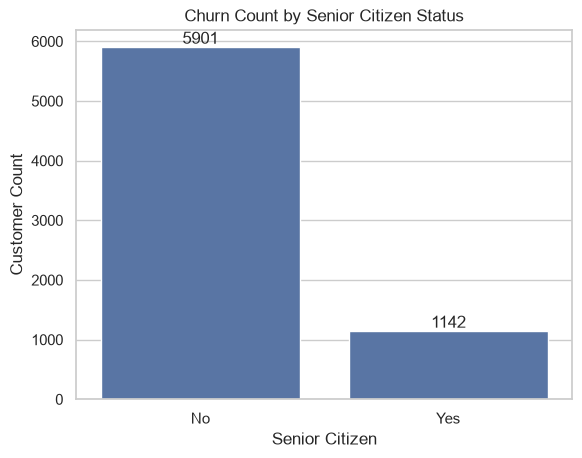

In [57]:
ax = sns.countplot(x='SeniorCitizen', data=customers)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Count by Senior Citizen Status')
plt.xlabel('Senior Citizen')
plt.ylabel('Customer Count')

plt.show()

In [58]:
customers.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [59]:
customers.head

<bound method NDFrame.head of       customerID  gender SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female            No     Yes         No       1   
1     5575-GNVDE    Male            No      No         No      34   
2     3668-QPYBK    Male            No      No         No       2   
3     7795-CFOCW    Male            No      No         No      45   
4     9237-HQITU  Female            No      No         No       2   
...          ...     ...           ...     ...        ...     ...   
7038  6840-RESVB    Male            No     Yes        Yes      24   
7039  2234-XADUH  Female            No     Yes        Yes      72   
7040  4801-JZAZL  Female            No     Yes        Yes      11   
7041  8361-LTMKD    Male           Yes     Yes         No       4   
7042  3186-AJIEK    Male            No      No         No      66   

     PhoneService     MultipleLines InternetService OnlineSecurity  ...  \
0              No  No phone service             DSL             No

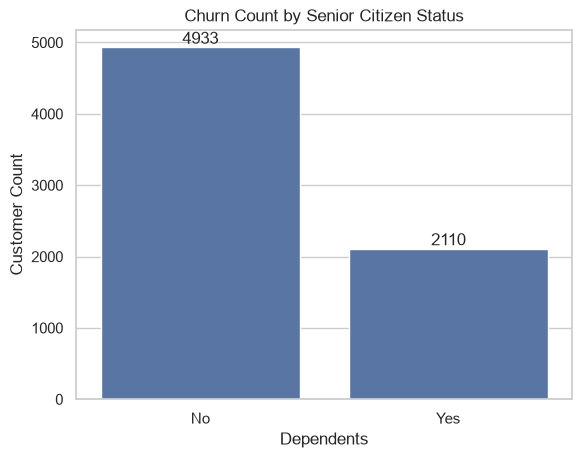

In [60]:
ax = sns.countplot(x='Dependents', data=customers)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Count by Senior Citizen Status')
plt.xlabel('Dependents')
plt.ylabel('Customer Count')

plt.show()

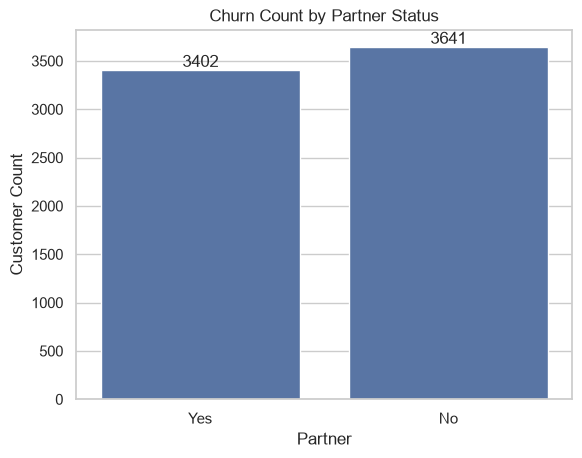

In [61]:
ax = sns.countplot(x='Partner', data=customers)

for container in ax.containers:
    ax.bar_label(container)

plt.title('Churn Count by Partner Status')
plt.xlabel('Partner')
plt.ylabel('Customer Count')

plt.show()

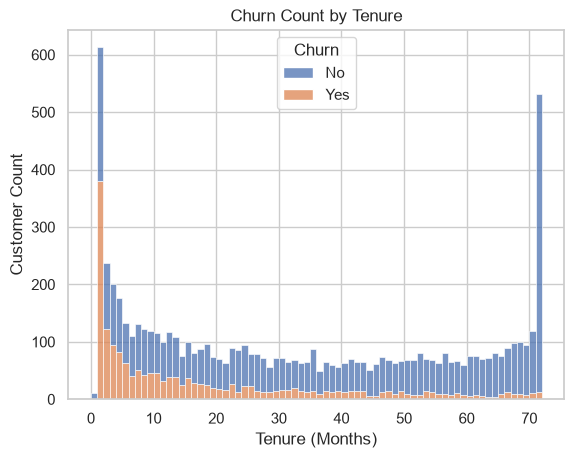

In [62]:
plt.Figure(figsize=(9, 4))
sns.histplot(data=customers, x='tenure', hue='Churn', multiple='stack', bins=72)
plt.title('Churn Count by Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Customer Count')
plt.show()

## Customer who have churn our services for Long and Short time have   Stayed

In [63]:
customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


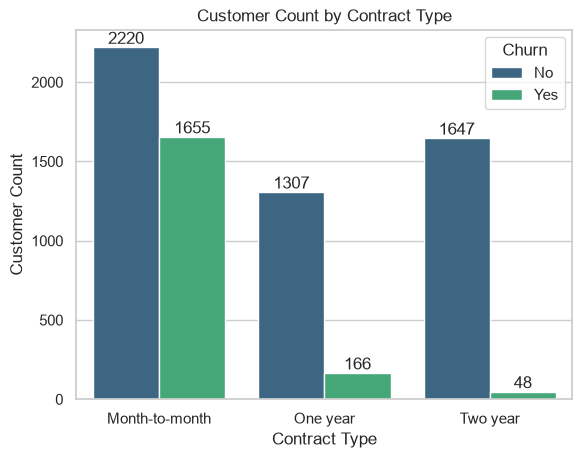

In [64]:
ax = sns.countplot(x='Contract', hue='Churn', data=customers, palette='viridis')

for container in ax.containers:
    ax.bar_label(container)

plt.title('Customer Count by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')

plt.show()

### Customers on month-to-month contracts are more likely to churn compared to customers with one-year or two-year contracts. This indicates that longer-term contracts are associated with better customer retention.

In [65]:
customers.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\261296522.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\261296522.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\261296522.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\261296522.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue

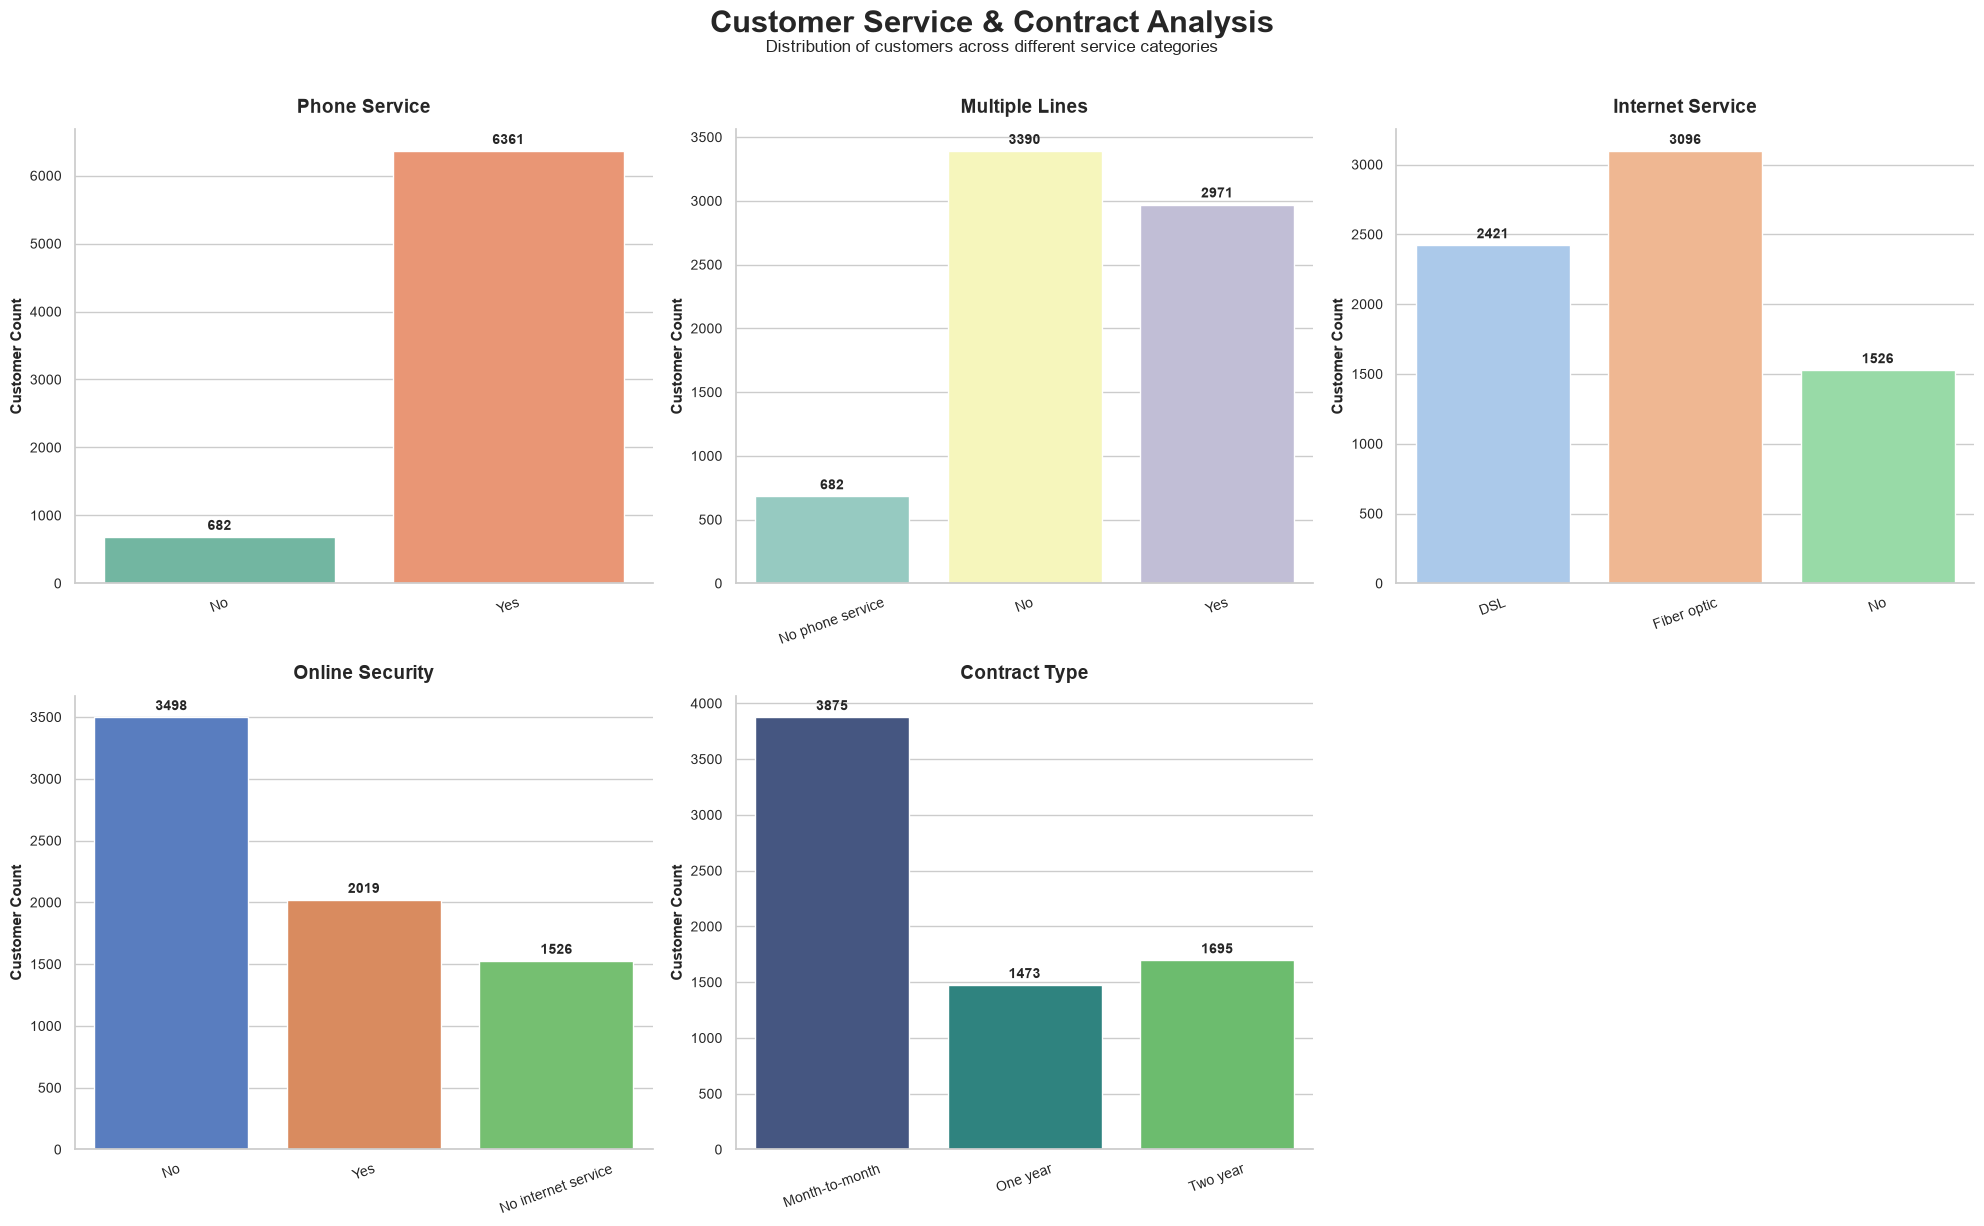

In [66]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set overall style
sns.set_theme(style="whitegrid")

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# Features
features = [
    'PhoneService',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'Contract'
]

# Titles
titles = [
    'Phone Service',
    'Multiple Lines',
    'Internet Service',
    'Online Security',
    'Contract Type'
]

# Different color palettes
palettes = [
    'Set2',
    'Set3',
    'pastel',
    'muted',
    'viridis'
]

# Create plots
for ax, feature, title, palette in zip(
    axes.flat, features, titles, palettes
):
    
    sns.countplot(
        x=feature,
        data=customers,
        ax=ax,
        palette=palette
    )
    
    # Add count labels
    for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=10,
            fontweight='bold',
            padding=3
        )
    
    # Title
    ax.set_title(
        title,
        fontsize=14,
        fontweight='bold',
        pad=12
    )
    
    # Axis labels
    ax.set_xlabel('')
    ax.set_ylabel(
        'Customer Count',
        fontsize=11,
        fontweight='bold'
    )
    
    # Rotate labels
    ax.tick_params(
        axis='x',
        labelrotation=20,
        labelsize=10
    )
    
    ax.tick_params(
        axis='y',
        labelsize=10
    )
    
    # Remove top and right borders
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# Remove unused 6th subplot
axes[1, 2].axis('off')


# Main title
fig.suptitle(
    'Customer Service & Contract Analysis',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

# Subtitle
fig.text(
    0.5,
    0.985,
    'Distribution of customers across different service categories',
    ha='center',
    fontsize=12
)

# Adjust layout
plt.tight_layout()

plt.show()

C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\464524216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\464524216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\464524216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
C:\Users\aryan\AppData\Local\Temp\ipykernel_5508\464524216.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` an

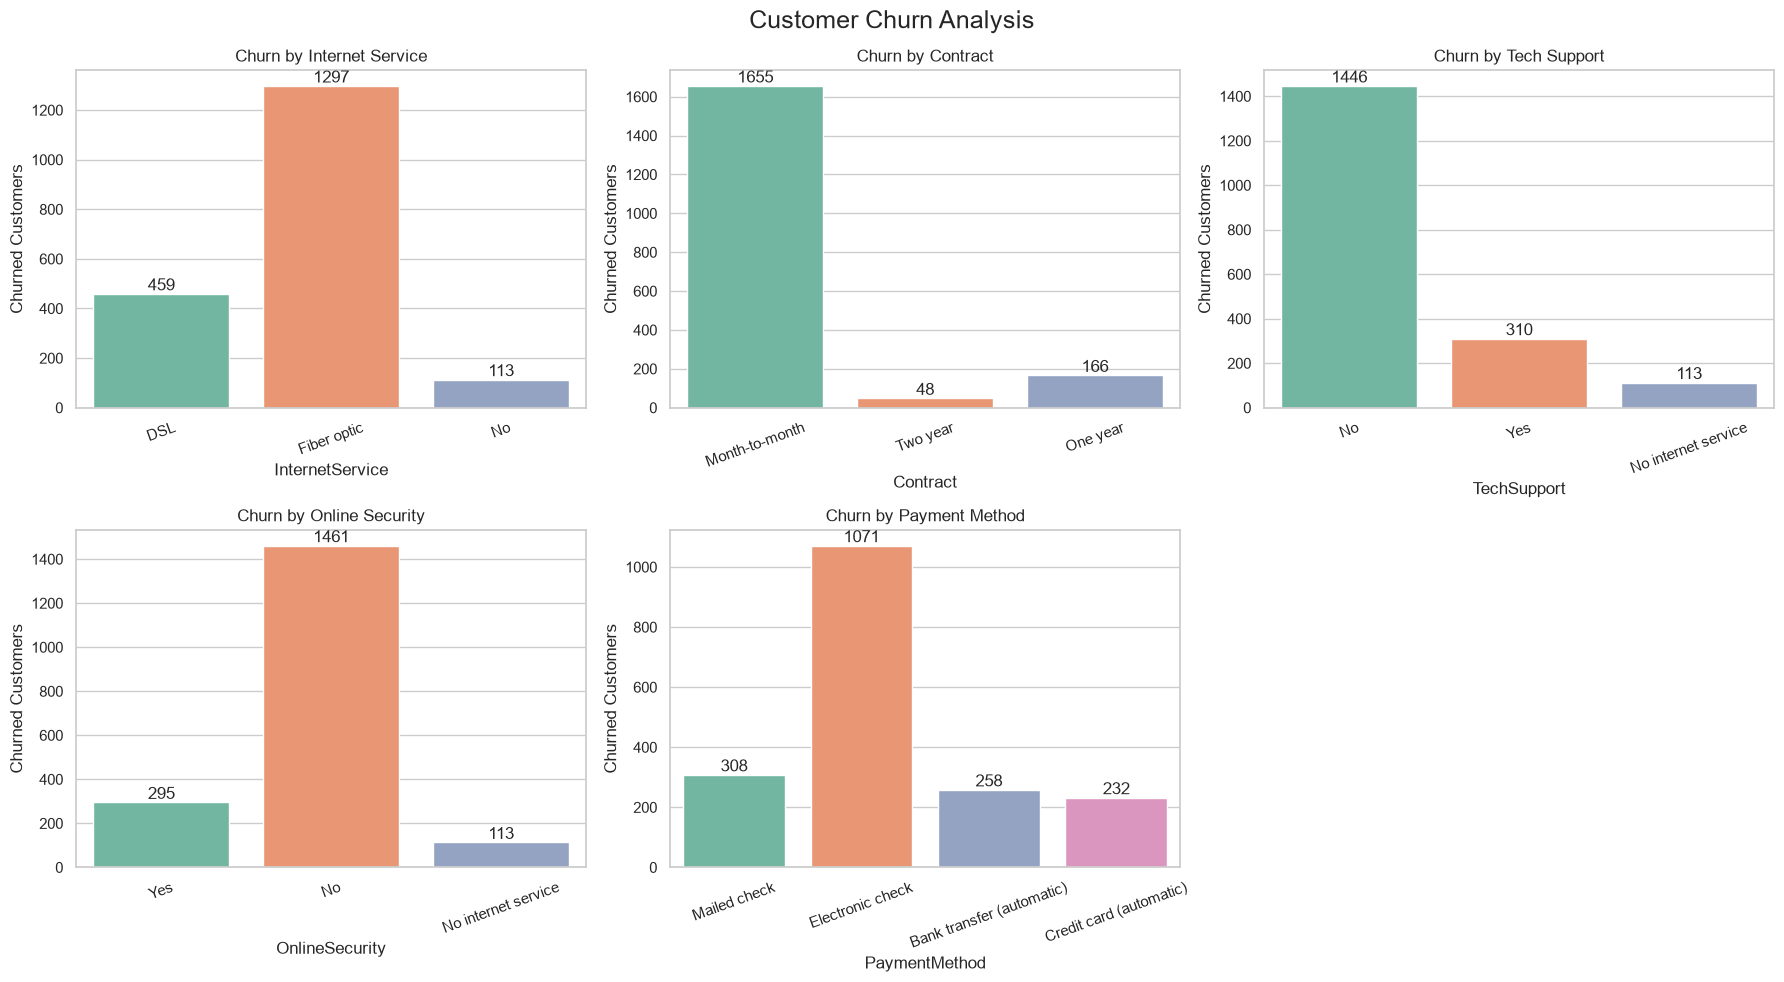

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

churned = customers[customers['Churn'] == 'Yes']

def churn_countplot(ax, column, title):
    sns.countplot(
        x=column,
        data=churned,
        ax=ax,
        palette='Set2'
    )
    
    for container in ax.containers:
        ax.bar_label(container)
        
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Churned Customers')
    ax.tick_params(axis='x', rotation=20)


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

churn_countplot(axes[0, 0], 'InternetService', 'Churn by Internet Service')
churn_countplot(axes[0, 1], 'Contract', 'Churn by Contract')
churn_countplot(axes[0, 2], 'TechSupport', 'Churn by Tech Support')
churn_countplot(axes[1, 0], 'OnlineSecurity', 'Churn by Online Security')
churn_countplot(axes[1, 1], 'PaymentMethod', 'Churn by Payment Method')

fig.delaxes(axes[1, 2])

plt.suptitle('Customer Churn Analysis', fontsize=18)
plt.tight_layout()
plt.show()

Contract × Tenure

Contract      Month-to-month  One year  Two year
TenureGroup                                     
0-6 Months             55.20     10.26      0.00
7-12 Months            42.00     10.59      0.00
13-24 Months           37.72      8.12      0.00
25-48 Months           32.92     10.62      2.19
49+ Months             26.02     12.93      3.33


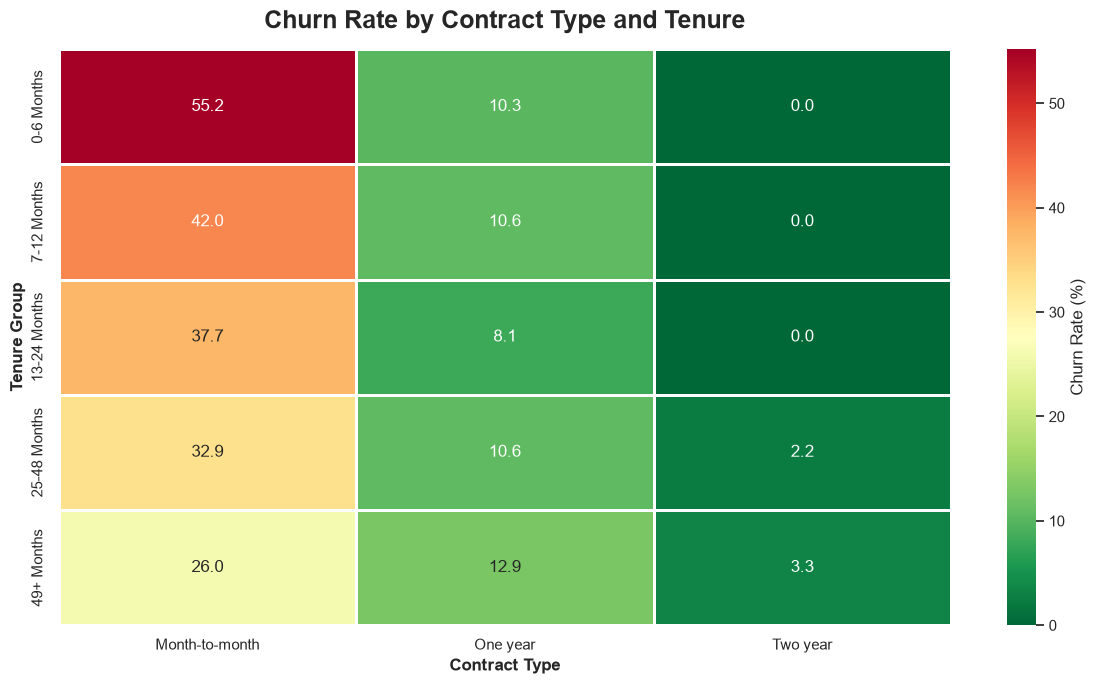

In [73]:
# ==============================
# CONTRACT × TENURE ANALYSIS
# ==============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create tenure groups
customers['TenureGroup'] = pd.cut(
    customers['tenure'],
    bins=[-1, 6, 12, 24, 48, float('inf')],
    labels=[
        '0-6 Months',
        '7-12 Months',
        '13-24 Months',
        '25-48 Months',
        '49+ Months'
    ]
)

# Create churn flag
customers['Churn_Flag'] = customers['Churn'].map({
    'Yes': 1,
    'No': 0
})

# Calculate churn rate
contract_tenure = pd.pivot_table(
    customers,
    values='Churn_Flag',
    index='TenureGroup',
    columns='Contract',
    aggfunc='mean'
) * 100

print(contract_tenure.round(2))

# Heatmap
plt.figure(figsize=(12, 7))

sns.heatmap(
    contract_tenure,
    annot=True,
    fmt='.1f',
    cmap='RdYlGn_r',
    linewidths=1,
    cbar_kws={'label': 'Churn Rate (%)'}
)

plt.title(
    'Churn Rate by Contract Type and Tenure',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Contract Type',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Tenure Group',
    fontsize=12,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Monthly Charges: Churners vs Stayers

In [74]:
charges_comparison = customers.groupby('Churn')['MonthlyCharges'].mean()

print(charges_comparison)

Churn
No     61.265124
Yes    74.441332
Name: MonthlyCharges, dtype: float64


Average Monthly Charges:
Churn
No     61.27
Yes    74.44
Name: MonthlyCharges, dtype: float64


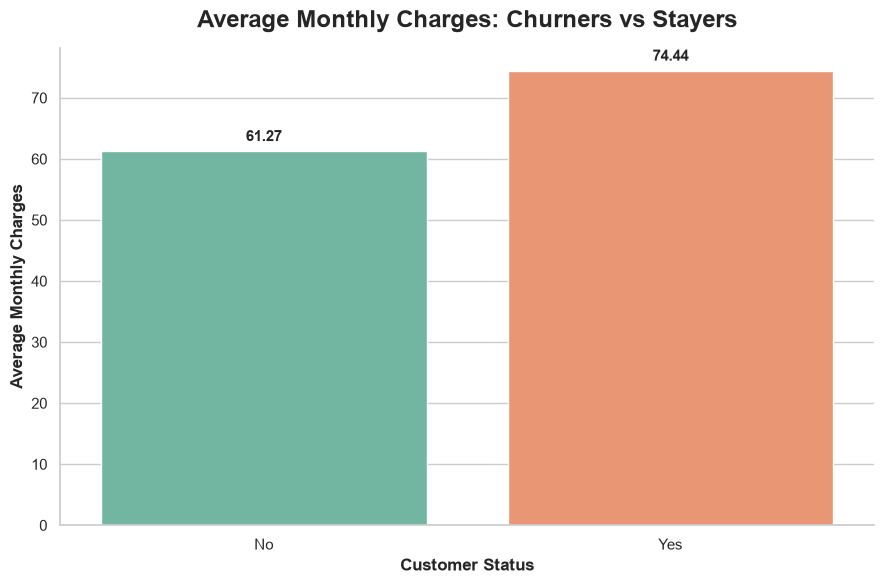

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average Monthly Charges for Churners and Stayers
charges_comparison = customers.groupby('Churn')['MonthlyCharges'].mean()

# Display values
print("Average Monthly Charges:")
print(charges_comparison.round(2))

# Create chart
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    x=charges_comparison.index,
    y=charges_comparison.values,
    hue=charges_comparison.index,
    palette='Set2',
    legend=False
)

# Add values on bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.2f',
        padding=5,
        fontsize=11,
        fontweight='bold'
    )

# Title
plt.title(
    'Average Monthly Charges: Churners vs Stayers',
    fontsize=17,
    fontweight='bold',
    pad=15
)

# Labels
plt.xlabel(
    'Customer Status',
    fontsize=12,
    fontweight='bold'
)

plt.ylabel(
    'Average Monthly Charges',
    fontsize=12,
    fontweight='bold'
)

# Remove unnecessary borders
sns.despine()

plt.tight_layout()
plt.show()

In [70]:
customers.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

## Risk Score

In [80]:
customers['RiskScore'] = 0

# Month-to-month contract
customers['RiskScore'] += (
    customers['Contract'] == 'Month-to-month'
).astype(int)

# Low tenure
customers['RiskScore'] += (
    customers['tenure'] <= 6
).astype(int)

# Electronic check payment
customers['RiskScore'] += (
    customers['PaymentMethod'] == 'Electronic check'
).astype(int)

# High monthly charges
customers['RiskScore'] += (
    customers['MonthlyCharges'] >= customers['MonthlyCharges'].median()
).astype(int)

In [81]:
risk_summary = customers.groupby('RiskScore').agg(
    Customers=('customerID', 'count'),
    MonthlyRevenue=('MonthlyCharges', 'sum'),
    ChurnRate=('Churn_Flag', 'mean')
)

risk_summary['ChurnRate'] *= 100

risk_summary.round(2)

,Customers,MonthlyRevenue,ChurnRate
RiskScore,,,
0,1474,51062.15,2.65
1,1967,140094.90,10.68
2,1898,127808.55,31.77
3,1334,106447.00,55.17
4,370,30704.00,75.95


## Revenue Currently at Risk

In [82]:
high_risk = customers[
    customers['RiskScore'] >= 3
]

high_risk_revenue = high_risk['MonthlyCharges'].sum()

print(
    f"High-Risk Customers: {len(high_risk):,}"
)

print(
    f"Monthly Revenue at Risk: ${high_risk_revenue:,.2f}"
)

High-Risk Customers: 1,704
Monthly Revenue at Risk: $137,151.00


In [83]:
annual_revenue_at_risk = high_risk_revenue * 12

print(
    f"Annual Revenue at Risk: ${annual_revenue_at_risk:,.2f}"
)

Annual Revenue at Risk: $1,645,812.00
